# HVSR analysis - Terraza 28

Session `CBUCF_titanSMA_1614_20230519_213500_02`: 24.303 minutes, 200 Hz, N/E/Z.
**Terraza 28 is the user-supplied site label**, not a location decoded from headers. Coordinates, orientation and calibration remain unverified.

Only the selected exploratory configuration is analyzed. Among the previously tested profiles with reliability 3/3, full frequency coverage and complete time blocks, selection prioritized clarity count, then the smallest tracked-peak deviation across chronological blocks, then accepted-window count. This yielded 20-second windows, bandwidth 40, linear detrending and frequency-domain rejection. The sweep used the same recording and is not independent validation.

**Exploratory only:** the selected 20-second profile now uses 50% overlap (10-second steps). It retains 69 correlated windows covering 14.83 unique minutes, versus 35 windows/11.67 minutes without overlap. The peak remains near 11.06 Hz with A0 about 1.41. Native reliability is 3/3 but clarity is only 3/6: SESAME still fails. Overlap reuses samples; native window-count-based cycle totals and scatter do not represent independent evidence. Chronological blocks contain stronger competing low-frequency peaks.


In [1]:
from pathlib import Path
from dataclasses import asdict
import hashlib
import importlib
import importlib.metadata
import platform
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

WORKING_DIR = Path.cwd().resolve()
ROOT = next((folder for folder in (WORKING_DIR, *WORKING_DIR.parents)
             if (folder / 'utils/hvsr_tools.py').is_file() and (folder / 'data').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Run from the repository root or main/01_processing.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from utils import hvsr_tools as hv
from utils import plotting as hp
hp = importlib.reload(hp)
hv = importlib.reload(hv)

versions = {name: importlib.metadata.version(name) for name in ('hvsrpy', 'obspy', 'numpy', 'scipy', 'pandas', 'matplotlib')}
versions['python'] = platform.python_version()

## 1. Inputs
 

In [2]:
import json

SESSION_ID = 'CBUCF_titanSMA_1614_20230519_213500_02'
SITE_LABEL = 'Terraza 28'
manifest = json.loads((ROOT / 'data/accelerometer/2023-05-19/sessions.json').read_text())
matches = [item for item in manifest['sessions'] if item['session_id'] == SESSION_ID]
if len(matches) != 1:
    raise ValueError(f'Expected exactly one catalog session: {SESSION_ID}')
session = matches[0]
INPUT_FILES = [ROOT / path for path in session['input_files']]
STARTTIME = session['starttime']
ENDTIME = session['endtime']
SAVE_OUTPUTS = True
OUTPUT_DIR = ROOT / 'outputs/terraza_28'
SHOW_WINDOW_CURVES = True
FIGURE_STYLE = hp.PaperStyle(width_in=6.4, font_size=7.0, tick_size=6.0, legend_size=6.0, dpi=300)
FIGURE_FORMATS = ('pdf', 'svg', 'png')

record = hv.load_record(INPUT_FILES, starttime=STARTTIME, endtime=ENDTIME)
if abs(record.meta['duration_s'] - session['duration_s']) > record.vt.dt_in_seconds:
    raise ValueError('Loaded duration disagrees with the catalog interval.')
record.meta.update(session_id=SESSION_ID, site_label=SITE_LABEL,
                   site_label_source='user supplied; not verified from headers',
                   start_bogota=session['start_bogota'], end_bogota=session['end_bogota'])
print(f"{SITE_LABEL}: {record.meta['duration_s'] / 60:.6f} minutes; "
      f"{session['start_bogota']} to {session['end_bogota']}")
display(pd.Series(record.meta, name='Recording'))

Terraza 28: 24.302833 minutes; 2023-05-19T16:35:24.665000-05:00 to 2023-05-19T16:59:42.835000-05:00


file name(s)                   [/home/orincon/ciudad-perdida-hvsr/data/accele...
deployed degrees from north                                                  0.0
current degrees from north                                                   0.0
station                                                                    CBUCF
starttime                                            2023-05-19T21:35:24.665000Z
sampling_rate_hz                                                           200.0
duration_s                                                               1458.17
session_id                                CBUCF_titanSMA_1614_20230519_213500_02
site_label                                                            Terraza 28
site_label_source                       user supplied; not verified from headers
start_bogota                                    2023-05-19T16:35:24.665000-05:00
end_bogota                                      2023-05-19T16:59:42.835000-05:00
Name: Recording, dtype: obje

## 2. Selected processing configuration

20-second continuous windows with 50% overlap (10-second steps); vector STA/LTA (2/30 seconds, 0.1-3.0), 2-second transient padding and crest-factor limit 15. Linear detrending, 5%-per-side taper, native bandwidth-40 Konno-Ohmachi smoothing, squared-average horizontals, 0.2-45 Hz and no FFT padding. Frequency-domain rejection uses n=2.5 and a maximum of 50 iterations. The broad peak-search band is preserved. Relaxed time-domain thresholds admit more impulsive signal than the earlier crest-6 profile; peak-based rejection and overlapping windows are not independent proof of stability.


In [26]:
params = hv.HVSRParams(
    # 1. Window duration and placement
    window_length_s=40.0,
    overlap_pct=0.0,
    window_selection='continuous',

    # 2. Time-domain screening of raw recordings
    anti_trigger=True,
    sta_s=2.0,
    lta_s=30.0,
    sta_lta_min=0.1,
    sta_lta_max=3.0,
    sta_lta_method='vector',
    sta_lta_amplitude='abs',
    transient_padding_s=2.0,
    max_crest_factor=15.0,
    clip_threshold_pct=None,

    # 3. Waveform preprocessing and FFT
    filter_corners_hz=(None, None),
    filter_order=5,
    detrend='linear',
    orient_to_degrees_from_north=None,
    taper_pct_per_side=5.0,
    fft_zero_padding=False,

    # 4. Spectral smoothing and horizontal combination
    smoothing='konno_and_ohmachi',
    smoothing_bandwidth=40.0,
    horizontal_combination='squared_average',

    # 5. Frequency sampling and peak-search band
    fmin=0.2,
    fmax=45.0,
    n_frequencies=800,
    frequency_spacing='log',
    peak_range_hz=None,

    # 6. Optional rejection based on H/V curves
    frequency_domain_rejection=True,
    fdr_n=2.5,
)
OUTPUT_PREFIX = f'terraza_28_{SESSION_ID}_{params.window_length_s:g}s_{params.overlap_pct:g}pct_overlap_selected_fdr'
result = hv.run_hvsr(record, params)
display(pd.Series(result.summary(), name='Analysis summary'))
fourier_data = hv.component_fourier_data(record, result)
component_spectra = fourier_data.smoothed

9/36 windows | f0=0.26950 Hz | A0=1.49180


n_grid_windows               36.000000
n_windows_time_selection      9.000000
n_candidates_before_crest    28.000000
n_crest_rejected             19.000000
n_windows                     9.000000
retained_fraction             0.250000
f0_mean_curve_hz              0.269502
A0_mean_curve                 1.491799
f0_windows_hz                 0.376526
f0_windows_low_hz             0.242169
f0_windows_high_hz            0.585425
f0_windows_std_hz             0.198676
A0_windows                    2.175785
fdr_iterations                1.000000
runtime_s                     0.036000
Name: Analysis summary, dtype: float64

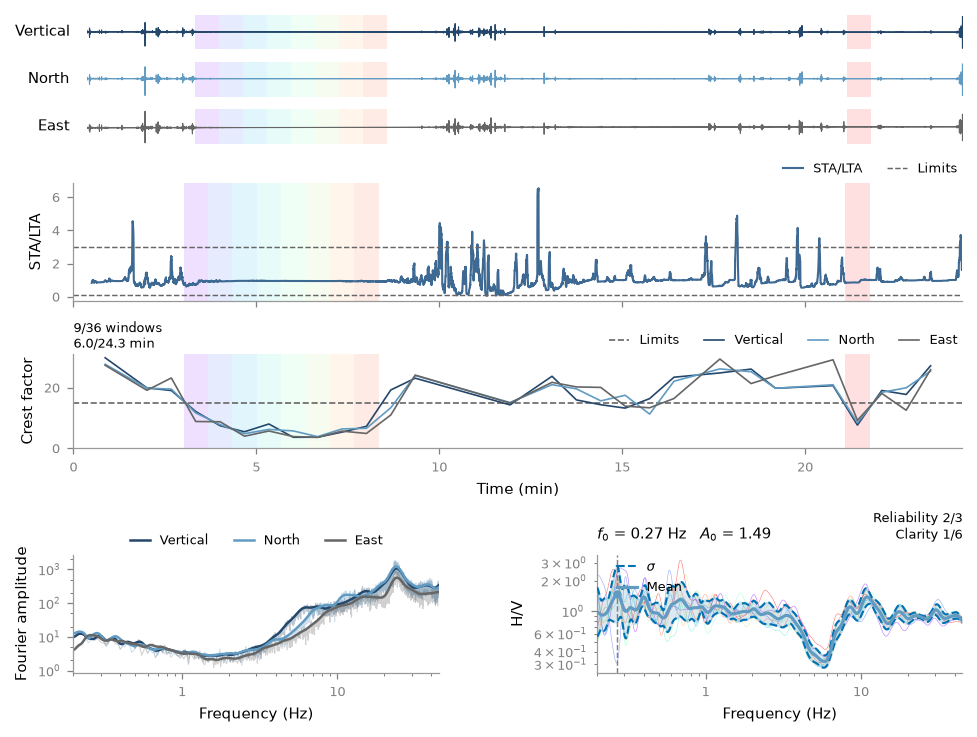

In [27]:
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

FIGURE_CONTROLS = {
    'height_in': 4.8,
    'show_raw_signals': True,
    'raw_height_ratio': 1.2,
    'height_ratios': (1.0, 1.0),
    'crest_height_ratio': 0.8,
    'crest_component_alpha': 1.0,
    'component_colors': {'Z': '#24476B', 'N': '#619BC2', 'E': '#666666'},
    'component_linestyles': {'Z': '-', 'N': '-', 'E': '-'},
    'line_width': 0.8,
    'fourier_line_width': 1.2,
    'fourier_grid': False,
    'window_cmap': 'rainbow',
    'accepted_alpha': 0.12,
    'sta_lta_ylim': None,
    'sta_lta_components': ('E',),
    'sta_lta_vector_color': '#3e6993ff',
    'sta_lta_line_width': 1.0,
    'sta_lta_alpha': 1.0,
    'fourier_yscale': 'log',
    'show_unsmoothed_fourier': True,
    'unsmoothed_fourier_alpha': 0.3,
    'unsmoothed_fourier_line_width': 0.5,
    'hvsr_yscale': None,
    'hvsr_window_alpha': 0.5,
    'hvsr_title_font_size': 7.0,
    'grid': False,
    'hspace': 0.04,  # Vertical spacing between rows
    'wspace': 0.15,  # Horizontal spacing between columns
}

def make_analysis_figure(record, result, component_spectra, controls, style, show_windows=False,
                         fourier_data=None):
    if controls['show_unsmoothed_fourier'] and fourier_data is None:
        raise ValueError('Rerun the processing cell to calculate unsmoothed Fourier amplitudes.')
    labels = {'Z': 'Vertical', 'N': 'North', 'E': 'East'}
    attributes = {'Z': 'vt', 'N': 'ns', 'E': 'ew'}
    if not controls['sta_lta_components'] or not set(controls['sta_lta_components']) <= set(labels):
        raise ValueError('sta_lta_components must contain N, E and/or Z.')
    dt = record.vt.dt_in_seconds
    time = np.arange(record.vt.n_samples) * dt / 60
    with hp.paper_context(style):
        figure = plt.figure(figsize=(style.width_in, controls['height_in']), layout='constrained')
        figure.get_layout_engine().set(
            hspace=controls['hspace'],
            wspace=controls['wspace'],
        )
        show_crest = result.params.max_crest_factor is not None
        ratios = list(controls['height_ratios'])
        if show_crest:
            ratios.insert(1, controls['crest_height_ratio'])
        raw_offset = int(controls['show_raw_signals'])
        if raw_offset:
            ratios.insert(0, controls['raw_height_ratio'])
        grid = figure.add_gridspec(len(ratios), 2, height_ratios=ratios)
        sta_lta_ax = figure.add_subplot(grid[raw_offset, :])
        crest_ax = figure.add_subplot(grid[raw_offset + 1, :], sharex=sta_lta_ax) if show_crest else None
        fourier_ax = figure.add_subplot(grid[-1, 0])
        hvsr_ax = figure.add_subplot(grid[-1, 1], sharex=fourier_ax)
        raw_axes = []
        if raw_offset:
            raw_grid = grid[0, :].subgridspec(3, 1, hspace=0.02)
            for index, (component, attribute) in enumerate(attributes.items()):
                axis = figure.add_subplot(raw_grid[index, 0], sharex=sta_lta_ax)
                signal = getattr(record, attribute)
                times, lower, upper = hp.waveform_envelope(signal.amplitude, dt)
                axis.fill_between(times, lower, upper, color=controls['component_colors'][component],
                                  edgecolor=controls['component_colors'][component],
                                  linewidth=0.5, rasterized=True, zorder=1)
                axis.set_ylabel(labels[component], rotation=0, ha='right', va='center',
                                labelpad=8, fontweight='normal')
                hp.style_axes(axis, style=style)
                axis.set_yticks([])
                axis.spines['left'].set_visible(False)
                axis.spines['bottom'].set_visible(False)
                axis.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
                raw_axes.append(axis)

        starts = result.window_starts_s[result.valid_mask] / 60
        ranks = np.argsort(np.argsort(starts))
        window_colors = plt.get_cmap(controls['window_cmap'])(ranks / max(len(starts) - 1, 1))
        length = result.params.window_length_s / 60
        polygons = [[(start, 0), (start + length, 0), (start + length, 1), (start, 1)]
                    for start in starts]
        time_axes = raw_axes + [sta_lta_ax] + ([crest_ax] if show_crest else [])
        for time_axis in time_axes:
            time_axis.add_collection(PolyCollection(
                polygons, transform=time_axis.get_xaxis_transform(),
                facecolors=window_colors, alpha=controls['accepted_alpha'],
                edgecolors='none', zorder=0))
        if show_crest:
            hp.plot_crest_factor(result, ax=crest_ax, style=style,
                                 show_decisions=False,
                                 component_alpha=controls['crest_component_alpha'],
                                 component_colors=controls['component_colors'])
            crest_ax.set_title('')
            crest_ax.legend(loc='lower right', bbox_to_anchor=(1, 1.02),
                            ncols=4, borderaxespad=0, fontsize=style.legend_size)
            sta_lta_ax.tick_params(labelbottom=False)
        displayed = ('R',) if result.params.sta_lta_method == 'vector' else controls['sta_lta_components']
        for component in displayed:
            label = 'STA/LTA' if component == 'R' else labels[component]
            ratio = result.diagnostics['sta_lta'].get(component)
            if ratio is None:
                if component == 'R':
                    ratio = hv.vector_sta_lta_ratio(record, result.params.sta_s, result.params.lta_s,
                                                   result.params.sta_lta_amplitude)
                else:
                    ratio = hv.sta_lta_ratio(getattr(record, attributes[component]).amplitude, dt,
                                            result.params.sta_s, result.params.lta_s,
                                            result.params.sta_lta_amplitude)
            finite = np.flatnonzero(np.isfinite(ratio))
            if not finite.size:
                warnings.warn(f'{label} STA/LTA has no finite values.', RuntimeWarning)
                continue
            color = controls['sta_lta_vector_color'] if component == 'R' else controls['component_colors'][component]
            sta_lta_ax.plot(time, ratio, color=color,
                            linestyle='-' if component == 'R' else controls['component_linestyles'][component],
                            lw=controls['sta_lta_line_width'], alpha=controls['sta_lta_alpha'],
                            label=label, rasterized=True)
        if result.params.anti_trigger:
            for index, limit in enumerate((result.params.sta_lta_min, result.params.sta_lta_max)):
                sta_lta_ax.axhline(limit, color='0.4', ls='--', lw=0.7,
                                  label='Limits' if index == 0 else None)
        sta_lta_ax.set(xlim=(0, (record.vt.n_samples - 1) * dt / 60),
                       xlabel='Time (min)', ylabel='STA/LTA')
        if show_crest:
            sta_lta_ax.set_xlabel('')
        if controls['sta_lta_ylim'] is not None:
            sta_lta_ax.set_ylim(controls['sta_lta_ylim'])
        handles, legend_labels = sta_lta_ax.get_legend_handles_labels()
        sta_lta_ax.legend(handles, legend_labels, ncols=3, loc='lower right',
                          bbox_to_anchor=(1, 1.02), borderaxespad=0)
        included_min = hv.accepted_signal_coverage(result)['unique_duration_min']
        total_min = (record.vt.n_samples - 1) * dt / 60
        selection_annotation = (
            f'{result.n_windows}/{result.n_grid_windows} windows\n'
            f'{included_min:.1f}/{total_min:.1f} min')
        annotation_ax = crest_ax if show_crest else sta_lta_ax
        annotation_ax.text(0, 1.02, selection_annotation, transform=annotation_ax.transAxes,
                        ha='left', va='bottom', fontsize=style.legend_size)

        for component, label in labels.items():
            if controls['show_unsmoothed_fourier']:
                visible = ((fourier_data.raw_frequency >= result.params.fmin)
                           & (fourier_data.raw_frequency <= result.params.fmax))
                raw = fourier_data.raw[component][:, visible]
                log_raw = np.full_like(raw, -np.inf)
                np.log(raw, out=log_raw, where=raw > 0)
                raw_mean = np.exp(log_raw.mean(axis=0))
                fourier_ax.plot(fourier_data.raw_frequency[visible], raw_mean,
                                color=controls['component_colors'][component],
                                alpha=controls['unsmoothed_fourier_alpha'],
                                lw=controls['unsmoothed_fourier_line_width'], zorder=1,
                                label='_nolegend_', rasterized=True)
            mean = np.exp(np.log(component_spectra[component]).mean(axis=0))
            fourier_ax.plot(result.frequency, mean, label=label,
                            color=controls['component_colors'][component],
                            linestyle=controls['component_linestyles'][component],
                            lw=controls['fourier_line_width'], zorder=2)
        fourier_ax.set(xscale='log', yscale=controls['fourier_yscale'],
                       xlim=(result.params.fmin, result.params.fmax), xlabel='Frequency (Hz)',
                       ylabel='Fourier amplitude')
        fourier_ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:g}'))
        fourier_ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02),
                          ncols=3, borderaxespad=0)
        hp.plot_hvsr(result, show_windows=show_windows, title='', ax=hvsr_ax,
                     yscale=controls['hvsr_yscale'],
                     window_alpha=controls['hvsr_window_alpha'],
                     window_cmap=controls['window_cmap'], style=style)
        peak_annotation = hvsr_ax.texts[0]
        peak_title = peak_annotation.get_text().replace('\n', '   ')
        peak_annotation.remove()
        hvsr_ax.set_title(peak_title, loc='center', y=1.1, pad=0,
                          fontweight='normal', math_fontfamily='dejavusans')
        hvsr_ax.title.set_x(0)
        hvsr_ax.title.set_horizontalalignment('left')
        hvsr_ax.title.set_verticalalignment('bottom')
        legend_handles, legend_labels = hvsr_ax.get_legend_handles_labels()
        legend_order = [legend_labels.index(label) for label in (r'$\sigma$', 'Mean')
                        if label in legend_labels]
        hvsr_ax.legend([legend_handles[index] for index in legend_order],
                       [legend_labels[index] for index in legend_order],
                       loc='upper left', bbox_to_anchor=(0.04, 1),
                       ncols=1, borderaxespad=0, fontsize=style.legend_size, frameon=False)
        sesame_metrics = hv.assess_sesame_quality(result, time_blocks=None)['metrics']
        sesame_label = (
            f"Reliability {sesame_metrics['reliability_count']}/3\n"
            f"Clarity {sesame_metrics['clarity_count']}/6")
        hvsr_ax.text(1, 1.1, sesame_label, transform=hvsr_ax.transAxes,
                     ha='right', va='bottom', fontsize=style.legend_size,
                     fontweight='normal')
        for axis in (sta_lta_ax, fourier_ax, hvsr_ax):
            hp.style_axes(axis, grid=controls['grid'], style=style)
        if controls['fourier_yscale'] == 'log':
            fourier_ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1,)))
            fourier_ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2, 5)))
            fourier_ax.yaxis.set_minor_formatter(NullFormatter())
        if controls['fourier_grid']:
            fourier_ax.grid(which='major', color='0.92', linewidth=0.4)
        hvsr_ax.title.set_fontsize(controls['hvsr_title_font_size'])
        return figure

analysis_figure = make_analysis_figure(record, result, component_spectra, FIGURE_CONTROLS,
                                       FIGURE_STYLE, show_windows=SHOW_WINDOW_CURVES,
                                       fourier_data=fourier_data)
plt.show()

## 3. SESAME report


In [25]:
quality = hv.assess_sesame_quality(result, time_blocks=4)
coverage = hv.accepted_signal_coverage(result)
display(pd.Series(coverage, name='Accepted signal coverage'))
if params.fmin < coverage['minimum_frequency_for_10_cycles_hz']:
    warnings.warn(f"The displayed band below {coverage['minimum_frequency_for_10_cycles_hz']:g} Hz contains fewer than 10 cycles per window; do not interpret it as well-resolved low-frequency resonance.", RuntimeWarning)
if params.overlap_pct > 0:
    warnings.warn('Overlapping windows are correlated. Native SESAME totals count reused samples; unique coverage is reported separately and is not an effective independent-window count.', RuntimeWarning)
display(pd.DataFrame(quality['criteria']))
print(f"Reliability: {quality['metrics']['reliability_count']}/3; clarity: {quality['metrics']['clarity_count']}/6")
if not quality['metrics']['frequency_coverage_complete']:
    warnings.warn('Frequency band does not cover f0/4 to 4*f0; low-frequency clarity assessment is incomplete.')
if not quality['metrics']['sesame_passed']:
    warnings.warn('SESAME requirements are not met. Treat this curve as exploratory, not a confirmed resonance.')


overlap_pct                            0.000000
accepted_windows                       3.000000
unique_duration_min                    2.000000
nominal_window_duration_min            2.000000
reused_duration_min                    0.000000
cycles_from_unique_coverage_at_f0     32.340237
minimum_frequency_for_10_cycles_hz     0.250000
independent_window_count                    NaN
Name: Accepted signal coverage, dtype: float64

/tmp/ipykernel_96556/1983654145.py:5: RuntimeWarning: The displayed band below 0.25 Hz contains fewer than 10 cycles per window; do not interpret it as well-resolved low-frequency resonance.
  warnings.warn(f"The displayed band below {coverage['minimum_frequency_for_10_cycles_hz']:g} Hz contains fewer than 10 cycles per window; do not interpret it as well-resolved low-frequency resonance.", RuntimeWarning)


,criterion,description,value,comparison,threshold,passed
0,R1,Cycles per window,10.780079,>,10.00,True
1,R2,Total cycles,32.340237,>,200.00,False
2,R3,"Maximum amplitude scatter in [f0/2, 2*f0]",1.943083,<,3.00,True
3,C1,Minimum amplitude below peak / A0,0.445422,<,0.50,True
4,C2,Minimum amplitude above peak / A0,0.485919,<,0.50,True
5,C3,Peak amplitude,1.717898,>,2.00,False
6,C4,Maximum relative shift of +/-1 sigma peaks,1.745632,<,0.05,False
7,C5,Window-peak standard deviation / f0,1.011741,<,0.20,False
8,C6,Amplitude scatter at f0,1.277511,<,2.50,True


Reliability: 2/3; clarity: 3/6


/tmp/ipykernel_96556/1983654145.py:11: UserWarning: Frequency band does not cover f0/4 to 4*f0; low-frequency clarity assessment is incomplete.
  warnings.warn('Frequency band does not cover f0/4 to 4*f0; low-frequency clarity assessment is incomplete.')
/tmp/ipykernel_96556/1983654145.py:13: UserWarning: SESAME requirements are not met. Treat this curve as exploratory, not a confirmed resonance.
  warnings.warn('SESAME requirements are not met. Treat this curve as exploratory, not a confirmed resonance.')


## Chronological stability of the selected profile

Keep the four time blocks as a check on this configuration, not as another parameter search. Nearby tracked peaks and global block peaks can disagree. A stable small bump does not compensate for stronger competing peaks.


,block,start_s,end_s,n_windows,f0_global_hz,A0_global,f0_tracked_hz,A0_tracked
0,1,0.0000,364.5425,14,0.399309,1.674483,0.595661,1.512924
1,2,364.5425,729.0850,11,0.659413,1.521944,0.659413,1.521944
2,3,729.0850,1093.6275,13,11.757601,1.541105,0.654959,1.309461
3,4,1093.6275,1458.1700,12,0.238546,1.646809,0.682146,1.632638


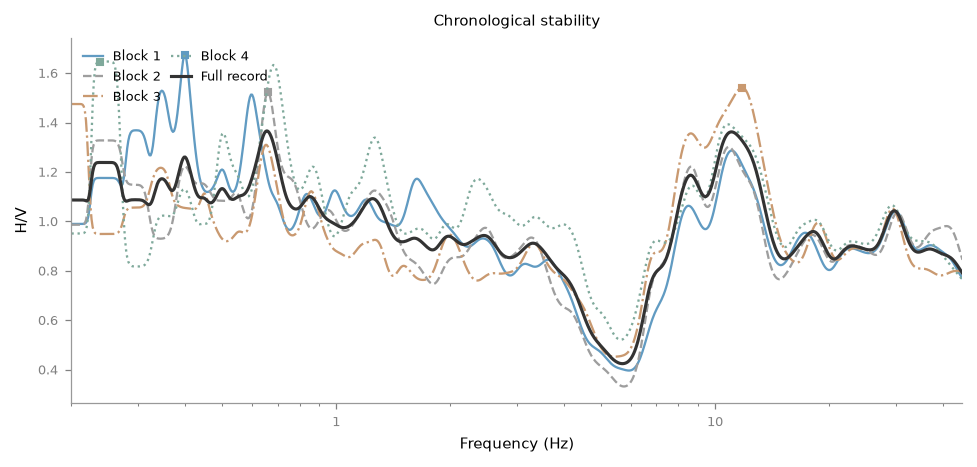

In [17]:
display(pd.DataFrame(quality['time_blocks']))
if not quality['metrics']['time_blocks_complete']:
    warnings.warn('Chronological validation is incomplete: at least one block lacks sufficient windows or a peak.', RuntimeWarning)
time_blocks_figure = hp.plot_time_blocks(result, quality, style=FIGURE_STYLE)
plt.show()


## 4. Component and window-peak diagnostics

N/Z and E/Z use the same accepted windows and preprocessing as the main analysis. They are ratios of separately smoothed component amplitudes, not a reconstruction of the combined-horizontal HVSR. Instrument axes are not verified geographic directions; unequal ratios alone do not prove geological anisotropy.

Compare the same time-selected curves before and after frequency-domain rejection. The window-peak plot distinguishes each window's main peak from the peak of the averaged curve. The +/-5% agreement count is a descriptive check, not an additional SESAME criterion; overlapping windows are correlated. No smoothing, search-band restriction or screening change is applied to manufacture a peak.

N_over_Z_at_mean_peak                         1.256253
E_over_Z_at_mean_peak                         1.222129
amplitude_before_rejection_at_mean_peak       1.355063
amplitude_after_rejection_at_mean_peak        1.366025
time_selected_windows                               53
spectrally_excluded_windows                          3
window_main_peaks_within_5pct_of_mean_peak           5
accepted_windows                                    50
agreement_relative_tolerance                      0.05
orientation_and_response_verified                False
Name: Peak diagnostics, dtype: object

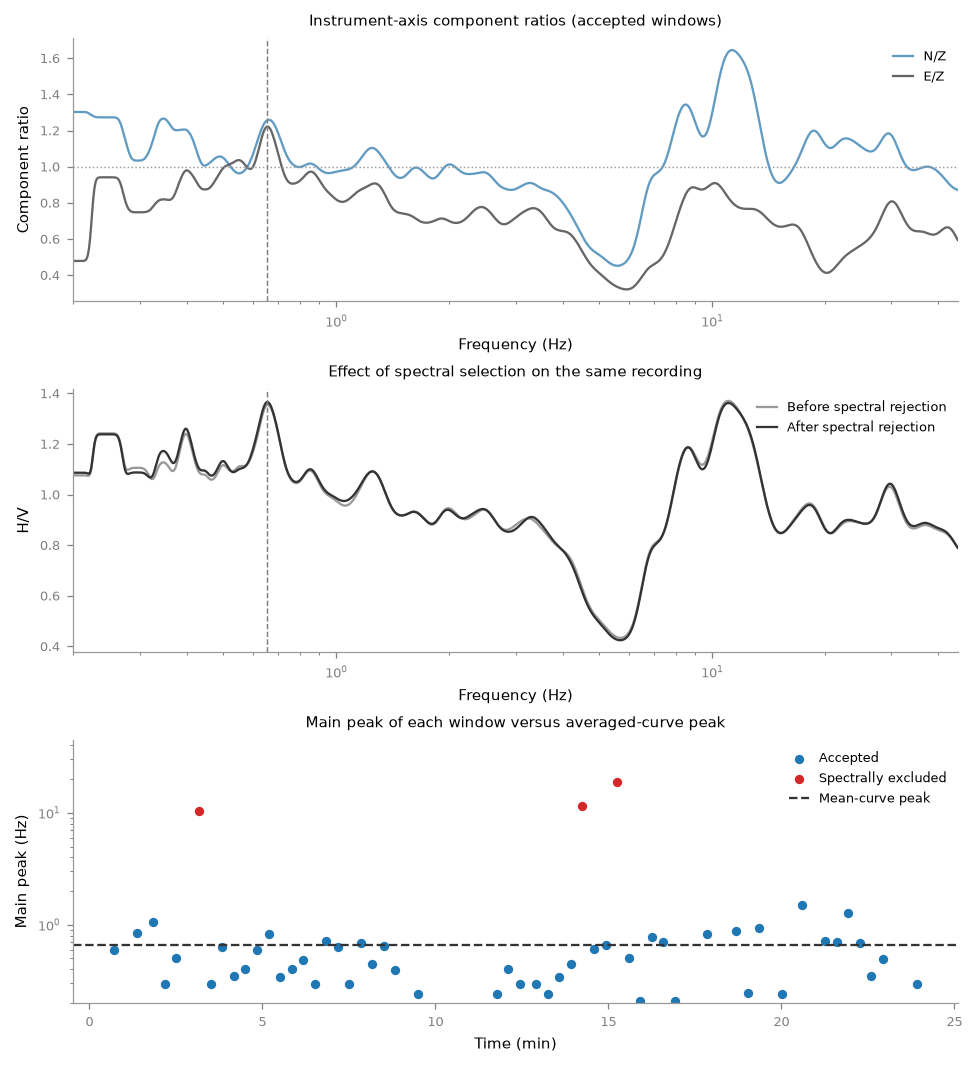

In [18]:
directional_ratios = {component: component_spectra[component] / component_spectra['Z']
                      for component in ('N', 'E')}
directional_means = {component: np.exp(np.log(values).mean(axis=0))
                     for component, values in directional_ratios.items()}
before_rejection = np.exp(np.log(result.hvsr.amplitude).mean(axis=0))
peak_index = int(np.argmin(abs(result.frequency - result.peak[0])))
peak_agreement_tolerance = 0.05
matching_peaks = abs(result.window_peaks[:, 0] / result.peak[0] - 1) <= peak_agreement_tolerance
peak_diagnostics = {
    'N_over_Z_at_mean_peak': float(directional_means['N'][peak_index]),
    'E_over_Z_at_mean_peak': float(directional_means['E'][peak_index]),
    'amplitude_before_rejection_at_mean_peak': float(before_rejection[peak_index]),
    'amplitude_after_rejection_at_mean_peak': float(result.mean_curve[peak_index]),
    'time_selected_windows': result.n_windows_time_selection,
    'spectrally_excluded_windows': result.n_windows_time_selection - result.n_windows,
    'window_main_peaks_within_5pct_of_mean_peak': int(matching_peaks.sum()),
    'accepted_windows': result.n_windows,
    'agreement_relative_tolerance': peak_agreement_tolerance,
    'orientation_and_response_verified': False,
}
display(pd.Series(peak_diagnostics, name='Peak diagnostics'))
if not matching_peaks.any():
    warnings.warn('No accepted window has its main peak within +/-5% of the mean-curve peak; the averaged peak is not a consistent window-main-peak estimate.', RuntimeWarning)
component_ratio_table = pd.DataFrame({
    'frequency_hz': result.frequency, 'N_over_Z': directional_means['N'],
    'E_over_Z': directional_means['E'], 'HV_before_rejection': before_rejection,
    'HV_after_rejection': result.mean_curve,
})
with hp.paper_context(FIGURE_STYLE):
    diagnostic_figure, diagnostic_axes = hp.paper_subplots(nrows=3, height_in=7.0, style=FIGURE_STYLE)
    component_ax, rejection_ax, peaks_ax = diagnostic_axes[:, 0]
    for component, mean in directional_means.items():
        component_ax.plot(result.frequency, mean, label=f'{component}/Z',
                          color=FIGURE_CONTROLS['component_colors'][component])
    component_ax.axhline(1, color='0.6', linestyle=':', linewidth=0.7)
    component_ax.set(ylabel='Component ratio', title='Instrument-axis component ratios (accepted windows)')
    rejection_ax.plot(result.frequency, before_rejection, label='Before spectral rejection', color='0.6')
    rejection_ax.plot(result.frequency, result.mean_curve, label='After spectral rejection', color='0.2')
    rejection_ax.set(ylabel='H/V', title='Effect of spectral selection on the same recording')
    for axis in (component_ax, rejection_ax):
        axis.set(xscale='log', xlim=(params.fmin, params.fmax), xlabel='Frequency (Hz)')
        axis.axvline(result.peak[0], color='0.5', linestyle='--', linewidth=0.7)
        axis.legend()
    midpoints_min = (result.window_starts_s + params.window_length_s / 2) / 60
    window_frequencies = result.hvsr._main_peak_frq
    for mask, label, color in ((result.valid_mask, 'Accepted', 'tab:blue'),
                               (~result.valid_mask, 'Spectrally excluded', 'tab:red')):
        finite = mask & np.isfinite(window_frequencies) & (window_frequencies > 0)
        peaks_ax.scatter(midpoints_min[finite], window_frequencies[finite], s=12, color=color, label=label)
    peaks_ax.axhline(result.peak[0], color='0.2', linestyle='--', label='Mean-curve peak')
    peaks_ax.set(yscale='log', ylim=(params.fmin, params.fmax), xlabel='Time (min)',
                 ylabel='Main peak (Hz)', title='Main peak of each window versus averaged-curve peak')
    peaks_ax.legend()
    for axis in diagnostic_axes[:, 0]:
        hp.style_axes(axis, style=FIGURE_STYLE)
plt.show()


## 5. Export


In [8]:
if SAVE_OUTPUTS:
    def input_hash(path):
        digest = hashlib.sha256()
        with path.open('rb') as handle:
            for chunk in iter(lambda: handle.read(1024 * 1024), b''):
                digest.update(chunk)
        return digest.hexdigest()
    paths = [Path(path) for path in record.meta['file name(s)']]
    metadata = {
        'quality': quality, 'versions': versions,
        'accepted_signal_coverage': coverage,
        'peak_diagnostics': peak_diagnostics,
        'figure_style': asdict(FIGURE_STYLE), 'figure_formats': FIGURE_FORMATS,
        'figure_controls': FIGURE_CONTROLS,
        'input_sha256': {str(path.relative_to(ROOT)) if path.is_relative_to(ROOT) else str(path): input_hash(path) for path in paths},
        'requested_interval_utc': {'starttime': STARTTIME, 'endtime': ENDTIME},
        'site_label': SITE_LABEL, 'site_label_source': 'user supplied', 'session_id': SESSION_ID,
        'interpretation': 'exploratory; selected profile still fails SESAME and has competing chronological peaks',
        'selection_basis': {
            'previously_tested_profiles': 48,
            'eligibility': 'reliability 3/3, full frequency coverage, complete chronological blocks',
            'ranking': 'clarity count descending; tracked block peak deviation ascending; accepted windows descending',
            'overlap_follow_up': '50% overlap added to the selected profile; other settings unchanged. Compared 0/25/50/75% overlap; clarity remained 3/6. Windows are correlated.',
            'independent_validation': False,
        },
    }
    exported = hv.save_outputs(result, OUTPUT_DIR, OUTPUT_PREFIX, extra=metadata)
    pd.DataFrame(quality['criteria']).to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_criteria.csv', index=False)
    pd.DataFrame(quality['time_blocks']).to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_time_blocks.csv', index=False)
    component_ratio_table.to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_component_ratios.csv', index=False)
    figure_exports = {
        'analysis': hp.save_figure(analysis_figure, OUTPUT_DIR / f'{OUTPUT_PREFIX}_analysis', formats=FIGURE_FORMATS, style=FIGURE_STYLE),
        'time_blocks': hp.save_figure(time_blocks_figure, OUTPUT_DIR / f'{OUTPUT_PREFIX}_time_blocks', formats=FIGURE_FORMATS, style=FIGURE_STYLE),
        'diagnostics': hp.save_figure(diagnostic_figure, OUTPUT_DIR / f'{OUTPUT_PREFIX}_diagnostics', formats=FIGURE_FORMATS, style=FIGURE_STYLE),
    }
    print('Saved to', OUTPUT_DIR)
    display(exported)
else:
    print('Output saving disabled.')


Saved to /home/orincon/ciudad-perdida-hvsr/outputs/terraza_28


{'curve': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/terraza_28/terraza_28_CBUCF_titanSMA_1614_20230519_213500_02_20s_50pct_overlap_selected_fdr_curve.csv'),
 'windows': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/terraza_28/terraza_28_CBUCF_titanSMA_1614_20230519_213500_02_20s_50pct_overlap_selected_fdr_windows.csv'),
 'summary': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/terraza_28/terraza_28_CBUCF_titanSMA_1614_20230519_213500_02_20s_50pct_overlap_selected_fdr_summary.json'),
 'selection': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/terraza_28/terraza_28_CBUCF_titanSMA_1614_20230519_213500_02_20s_50pct_overlap_selected_fdr_selection.csv')}